In [1]:
"""Muspan module."""

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import muspan as ms

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



In [8]:

def extract_sample_id(output_dir: Path) -> str:
    """Extract sample ID from Xenium output directory name.

    Args:
        output_dir: Path to the Xenium output directory.

    Returns:
        Sample ID extracted from the directory name (e.g., 'ROI1').
    """
    name = output_dir.name

    if not name.startswith("output-"):
        raise ValueError(f"Unexpected format: {name}")

    core = name[len("output-") :]  # remove prefix
    parts = core.split("__")

    if len(parts) < 3:
        raise ValueError(f"Unexpected structure: {name}")

    return parts[2]


def xenium_path(base: Path) -> Path:
    """Returns the path to the Xenium data directory.

    Args:
        base: The base directory containing the Xenium data.

    Returns:
        Dictionary of ROI name and path to the Xenium data directory.
    """
    run_dirs = sorted(base.glob("*SP25164_SARA_PATTI_RUN_*"))
    xenium_file_dict = {}

    for run_dir in run_dirs:
        # Confirm run_dir is a directory
        if not run_dir.is_dir():
            continue

        print(f"Run: {run_dir.name}")

        # find output-* directories inside each run
        output_dirs = sorted(run_dir.glob("output-*"))

        for out_dir in output_dirs:
            if not out_dir.is_dir():
                continue

            print(f"Output: {out_dir.name}")
            roi_name = extract_sample_id(out_dir)

            xenium_file_dict[roi_name] = out_dir
    return xenium_file_dict


In [3]:
def map_cell_types_to_domain(cell_id_to_type_df, domain, adata_cell_id, cluster_labels):
    """Maps cell type (cluster) labels from an df to a domain object on cell ID.

    Args:
        cell_id_to_type_df (pd.DataFrame):
            A DataFrame containing cell IDs and their corresponding types.
        domain: An object representing a spatial or logical domain, with cell IDs
            accessible via `domain.labels["Cell ID"]["labels"]` and a method
            `add_labels` for adding new labels.
        adata_cell_id (str): The column name in `adata.obs` that contains the cell
            IDs.
        cluster_labels (str): The column name in `adata.obs` that contains the
            cluster or cell type labels.

    Returns:
        None. The function modifies the `domain` object in place by adding a
        new label with the mapped cell types.
    """
    # Get cell IDs from the domain in their original order (preserving duplicates if any)
    domain_cell_ids_ordered = [
        str(cell_id) for cell_id in domain.labels["Cell ID"]["labels"]
    ]

    # Get unique cell IDs for filtering adata
    domain_cell_ids_unique = set(domain_cell_ids_ordered)

    print(f"Number of unique cells in the domain: {len(domain_cell_ids_unique)}")
    print(
        f"Total cell entries in domain (including duplicates): "
        f"{len(domain_cell_ids_ordered)}"
    )

    # Filter adata to include only cells in the area of interest
    filt_cell_id_to_type_df = cell_id_to_type_df[
        cell_id_to_type_df[adata_cell_id].isin(domain_cell_ids_unique)
    ]  # filter adata object

    print(
        f"Filtered adata from {len(cell_id_to_type_df)} to {len(filt_cell_id_to_type_df)} cells"
    )

    # Add cell cluster IDs
    print("Adding cell_type IDs to domain with cluster labels")

    # Create a mapping from cell_id to cell_type on filtered data
    cell_id_to_type = dict(
        zip(
            filt_cell_id_to_type_df[adata_cell_id],
            filt_cell_id_to_type_df[cluster_labels],
        )
    )

    # Get cell types in the same order as domain cell IDs
    cell_types_ordered = [
        cell_id_to_type.get(cell_id, "Unknown") for cell_id in domain_cell_ids_ordered
    ]

    # Add cell_type label to the domain
    domain.add_labels(label_name="Cell Type", labels=cell_types_ordered)
    print(f"Label keys in domain: {domain.labels.keys()}")
    print(f"Length of cell_types_ordered: {len(cell_types_ordered)}")
    print(f"Length of domain cell IDs: {len(domain_cell_ids_ordered)}")
    print(
        f"Number of 'Unknown' cell types: {cell_types_ordered.count('Unknown')}"
    )

    # Return muspan domain with cell types mapped
    return domain


In [3]:
# Set paths
base_dir = Path(
    "Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)

input_dir = base_dir / "data" / "xenium_raw"
out_dir = base_dir / "output" / "muspan"
module_dir = out_dir / "domains"
module_dir.mkdir(parents=True, exist_ok=True)


In [11]:
# # Make list of all paths to Xenium files
# paths = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/data/xenium_raw")
# xenium_paths = xenium_path(paths)

# cell_id_to_type_df = pd.read_csv("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/cell_id_to_cluster_labels.csv")

In [4]:
domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")


MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 183019
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [5]:
# Query to isolate cell boundaries
boundCells = ms.query.query(domain, ('Collection',), 'is', 'Cell boundaries')
print(boundCells)

centCell = ms.query.query(domain, ('Collection',), 'is', 'Cell centroids')
print(centCell)

Collection value is 0
Collection value is 3


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

<Figure size 500x500 with 0 Axes>

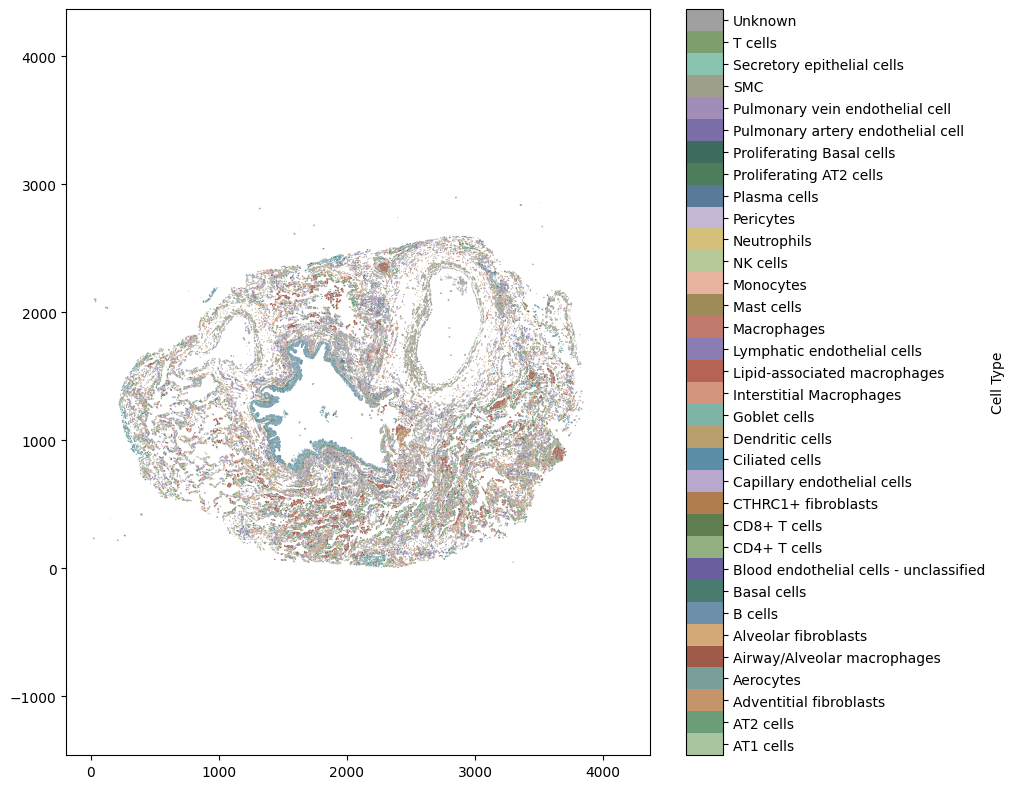

<Figure size 500x500 with 0 Axes>

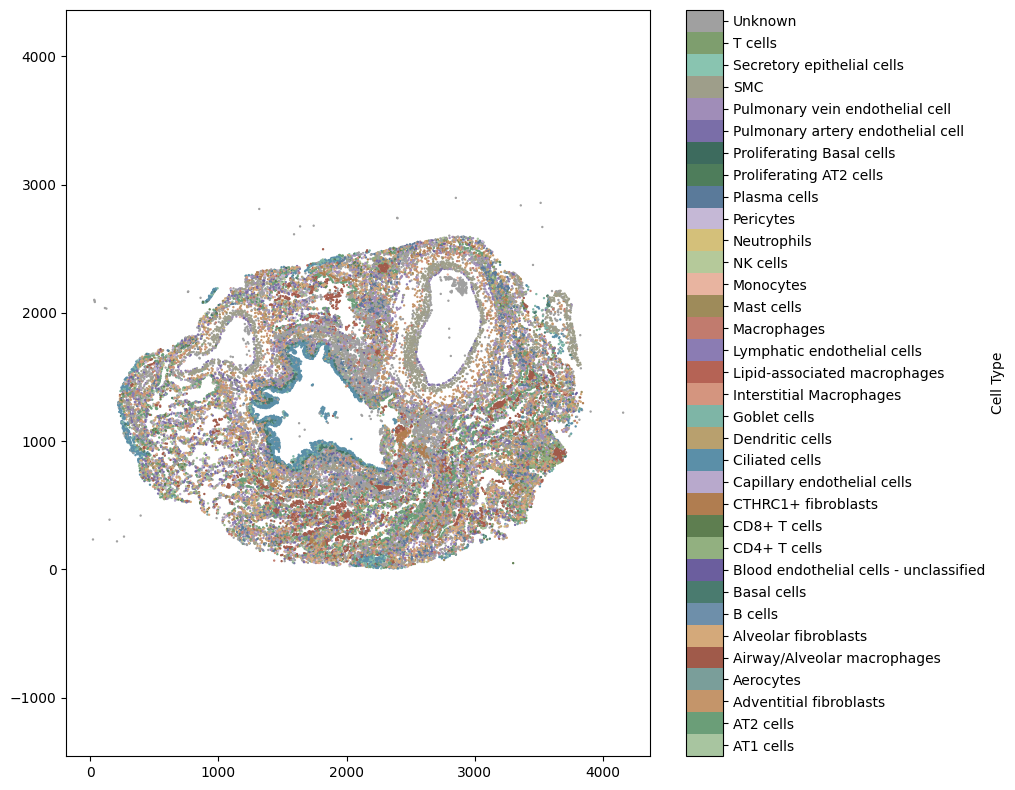

In [6]:
# Visualise cells, colored by 'Cluster ID'
plt.figure(figsize=(5, 5))
ms.visualise.visualise(
    domain,
    color_by=('label', 'Cell Type'),
    objects_to_plot=boundCells,
    shape_kwargs=dict(alpha=1, linewidth=0.01, edgecolor="#00000000")
)
plt.figure(figsize=(5, 5))
ms.visualise.visualise(domain, color_by=('label', 'Cell Type'), objects_to_plot=centCell, marker_size=0.5)

In [7]:
ms.networks.generate_network(
    domain,
    network_name="Delaunay CC",
    network_type="Delaunay",
    objects_as_nodes=("collection", "Cell centroids"),
)

ms.networks.generate_network(
    domain,
    network_name="Delaunay CC filtered",
    network_type="Delaunay",
    objects_as_nodes=("collection", "Cell centroids"),
    min_edge_distance=0,
    max_edge_distance=30,
)

# Proximity network with 30μm max distance
ms.networks.generate_network(
    domain,
    network_name="Proximity_30um",
    network_type="Proximity",
    objects_as_nodes=("collection", "Cell centroids"),
    max_edge_distance=30,
    min_edge_distance=0,
)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


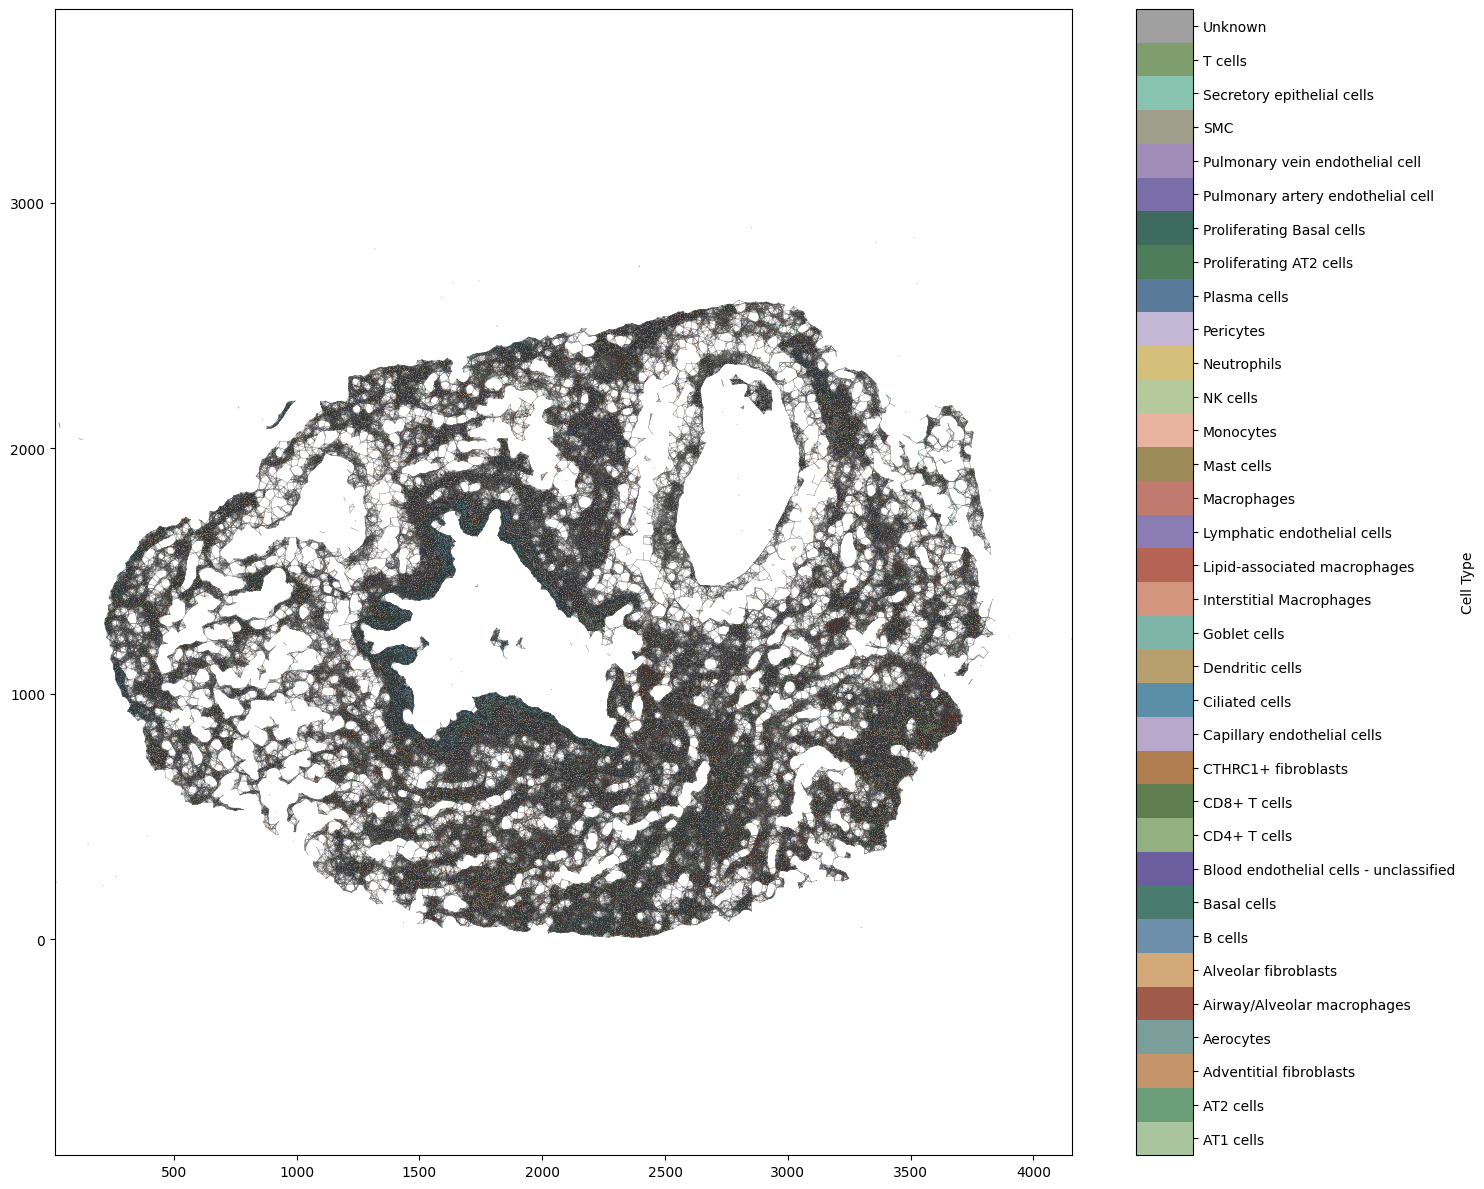

In [24]:
ms.visualise.visualise_network(
    domain,
    network_name="Proximity_30um",
    edge_weight_name=None,
    edge_width=0.2,
    edge_cmap="#060606",
    add_cbar=False,
    figure_kwargs=dict(figsize=(15, 12)),
    visualise_kwargs=dict(
        objects_to_plot=("collection", "Cell centroids"),
        marker_size=0.5,
        add_cbar=True,
        color_by=("label", "Cell Type"),
        scatter_kwargs=dict(        # ← linewidths/edgecolors go HERE
            edgecolors="none",
        ),
    ),
)
plt.savefig("proximity_network_30um.pdf")

In [31]:
SES,SES_p_val_filtered,label_categories = ms.networks.adjacency_permutation_test(domain,
                                                                                 network_name='Delaunay CC filtered',
                                                                                 label_name='Cell Type',
                                                                                 alpha=0.05,
                                                                                 label_shuffle_iterations=100)

 'Pulmonary artery endothelial cell' 'nan'] as these have fewer than 15 observations.


In [37]:
SES_p_val_filtered_df = pd.DataFrame(SES_p_val_filtered, index=label_categories, columns=label_categories)
SES_p_val_filtered_df.shape

(28, 28)

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

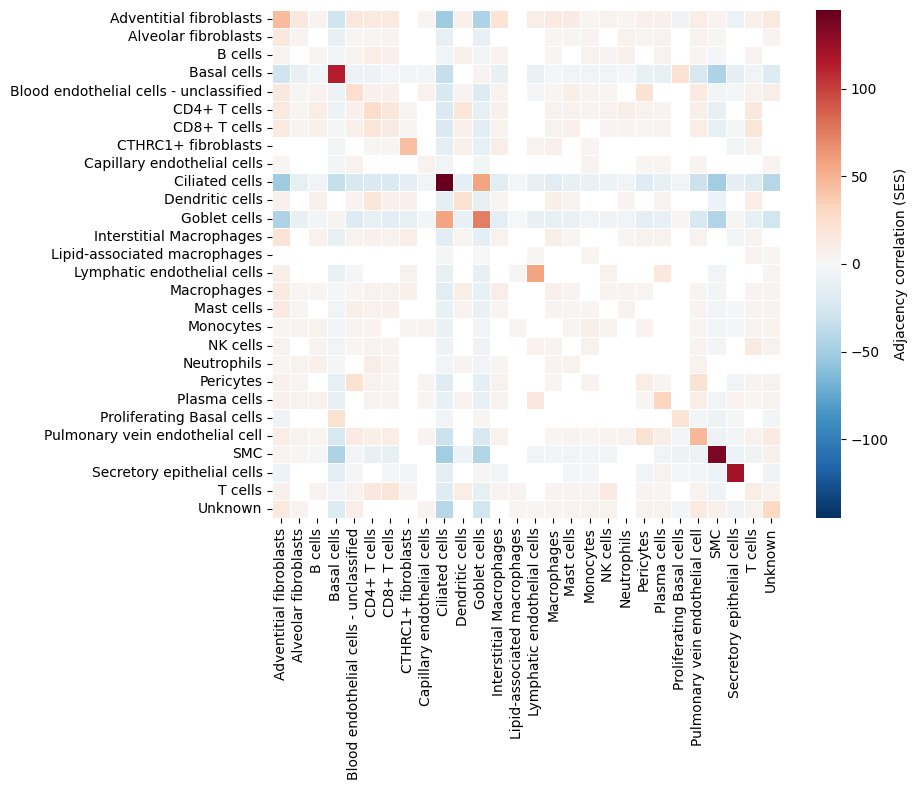

In [34]:
ms.visualise.visualise_correlation_matrix(SES_p_val_filtered,label_categories,colorbar_label='Adjacency correlation (SES)')

In [2]:
# Define functions
from matplotlib.patches import Patch


def load_adjacency_p_values(input_dir: Path):
    """Load adjacency permutation test p-values for each ROI.

    Parameters:
        input_dir : Path
            Directory containing APT permutation test

    Returns:
        dict
            {roi_name: dataframe}

    """
    results = {}

    for file in sorted(input_dir.glob("adjacency_permutation_test_p_values_*.csv")):
        roi = file.stem.removeprefix("adjacency_permutation_test_p_values_")
        df = pd.read_csv(file, index_col=0)

        results[roi] = df

    return results

def make_clustermap(
    cell_type, celltype_dict, meta, meta_cols, cmap="vlag", fig_path=None
):
    """Make clustermap of APT scores for a given cell type.

    Args:
        cell_type (str): Cell type to plot
        celltype_dict (dict): Dictionary of dataframes for cell type across conditions
        meta (pd.DataFrame): Metadata dataframe with ROI information
        meta_cols (list): List of metadata columns to include in annotations
        cmap (str): Colormap for heatmap
        fig_path (Path): Path to save figure

    Returns:
        sns.ClusterGrid: ClusterGrid object containing the clustermap

    """
    safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")

    # Build matrix
    celltype_df = pd.DataFrame(celltype_dict[cell_type])
    heatmap_df = celltype_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Validate metadata
    for col in meta_cols:
        if col not in meta.columns:
            raise ValueError(f"Missing metadata column: {col}")

    meta_subset = meta.loc[heatmap_df.columns, meta_cols]

    # Build color annotations + store palettes
    col_colors = pd.DataFrame(index=heatmap_df.columns)
    palettes = {}

    for col in meta_cols:
        # Unique values
        unique_vals = meta_subset[col].unique()

        # Number of unique values
        length = len(unique_vals)

        palette = dict(zip(unique_vals, sns.color_palette("husl", length)))

        palettes[col] = palette
        col_colors[col] = meta_subset[col].map(palette)

    # Plot
    g = sns.clustermap(
        heatmap_df,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        figsize=(12, 8),
        col_colors=col_colors,
        row_cluster=True,
        col_cluster=False,
        xticklabels=True,
        yticklabels=True,
    )

    g.figure.suptitle(f"{cell_type} - APT Scores", y=1.02)

    # Build legend (outside plot)
    legend_handles = []

    for col in meta_cols:
        for level, color in palettes[col].items():
            legend_handles.append(Patch(facecolor=color, label=f"{col}: {level}"))

    g.ax_heatmap.legend(
        handles=legend_handles,
        title="Metadata",
        bbox_to_anchor=(1.6, 1),
        loc="upper left",
        frameon=False,
    )

    # Save figure
    # plt.savefig(
    #     fig_path / f"{safe_cell_type}_nhood_enrichment_clustermap.pdf",
    #     bbox_inches="tight",
    # )
    # plt.close()


# Base project path
base_path = Path(
    "/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)

# Input
input_dir = base_path / "output" / "muspan" / "adjacency_permutation_test_results"

# Load metadata
meta = pd.read_csv(
    base_path / "data/meta/STx_meta_analysis_only_cleaned.csv", index_col=0
)

In [3]:
# Import adjacency permutation test
ROI_APT_dict = load_adjacency_p_values(input_dir)# 

# Get list of all cell types across conditions
cell_type_list = next(iter(ROI_APT_dict.values())).index.tolist()

# Make empty dict to store combined dataframes for each cell type
celltype_dict = {}

# Combine dataframes for each cell type across conditions
for cell_type in cell_type_list:
    combined = pd.DataFrame(
        {
            condition: df.loc[cell_type]
            if cell_type in df.index
            else pd.Series(float("nan"), index=df.columns)
            for condition, df in ROI_APT_dict.items()
        }
    )

    celltype_dict[cell_type] = combined


In [41]:
celltype_dict["Adventitial fibroblasts"].columns

Index(['COPD_46005_V1', 'COPD_46005_V2', 'COPD_R003_V1', 'COPD_R003_V2',
       'COPD_R003_V3', 'COPD_R009_V1', 'COPD_R009_V2', 'COPD_R009_V3',
       'COPD_R010_V2', 'COPD_R011_V1', 'COPD_R011_V2', 'COPD_R011_V3',
       'COPD_R014_V1', 'COPD_R014_V2', 'COPD_R014_V3', 'COPD_R021_V1',
       'COPD_R021_V2', 'COPD_R021_V3', 'COPD_R025_V1', 'COPD_R025_V2',
       'COPD_R025_V3', 'COPD_R035_V1', 'COPD_R035_V2', 'COPD_R035_V3',
       'COPD_R036_V1', 'COPD_R036_V2', 'COPD_R036_V3', 'COPD_R038_V1',
       'COPD_R038_V2', 'COPD_R038_V3', 'COPD_R039_V1', 'COPD_R039_V2',
       'COPD_R039_V3', 'COPD_R041_V1', 'COPD_R041_V2', 'COPD_R041_V3',
       'IPF_RBH_01', 'IPF_RBH_02', 'IPF_RBH_03', 'IPF_RBH_04', 'IPF_RBH_06',
       'IPF_RBH_14', 'IPF_RBH_15', 'IPF_RBH_16', 'IPF_RBH_18', 'IPF_RBH_19',
       'MICA_III_319_315_311', 'MICA_III_325_337_379', 'PM08_159', 'PM08_162',
       'PM08_163', 'PM08_164', 'PM08_167', 'PM08_169'],
      dtype='object')

In [4]:
# Drop ROI names from celltype_dict
ROI_to_drop = ["MICA_III_319_315_311", "MICA_III_325_337_379"]
for cell_type in cell_type_list:
    celltype_dict[cell_type] = celltype_dict[cell_type].drop(columns=ROI_to_drop)

In [5]:
celltype_dict["Adventitial fibroblasts"].columns

Index(['COPD_46005_V1', 'COPD_46005_V2', 'COPD_R003_V1', 'COPD_R003_V2',
       'COPD_R003_V3', 'COPD_R009_V1', 'COPD_R009_V2', 'COPD_R009_V3',
       'COPD_R010_V2', 'COPD_R011_V1', 'COPD_R011_V2', 'COPD_R011_V3',
       'COPD_R014_V1', 'COPD_R014_V2', 'COPD_R014_V3', 'COPD_R021_V1',
       'COPD_R021_V2', 'COPD_R021_V3', 'COPD_R025_V1', 'COPD_R025_V2',
       'COPD_R025_V3', 'COPD_R035_V1', 'COPD_R035_V2', 'COPD_R035_V3',
       'COPD_R036_V1', 'COPD_R036_V2', 'COPD_R036_V3', 'COPD_R038_V1',
       'COPD_R038_V2', 'COPD_R038_V3', 'COPD_R039_V1', 'COPD_R039_V2',
       'COPD_R039_V3', 'COPD_R041_V1', 'COPD_R041_V2', 'COPD_R041_V3',
       'IPF_RBH_01', 'IPF_RBH_02', 'IPF_RBH_03', 'IPF_RBH_04', 'IPF_RBH_06',
       'IPF_RBH_14', 'IPF_RBH_15', 'IPF_RBH_16', 'IPF_RBH_18', 'IPF_RBH_19',
       'PM08_159', 'PM08_162', 'PM08_163', 'PM08_164', 'PM08_167', 'PM08_169'],
      dtype='object')

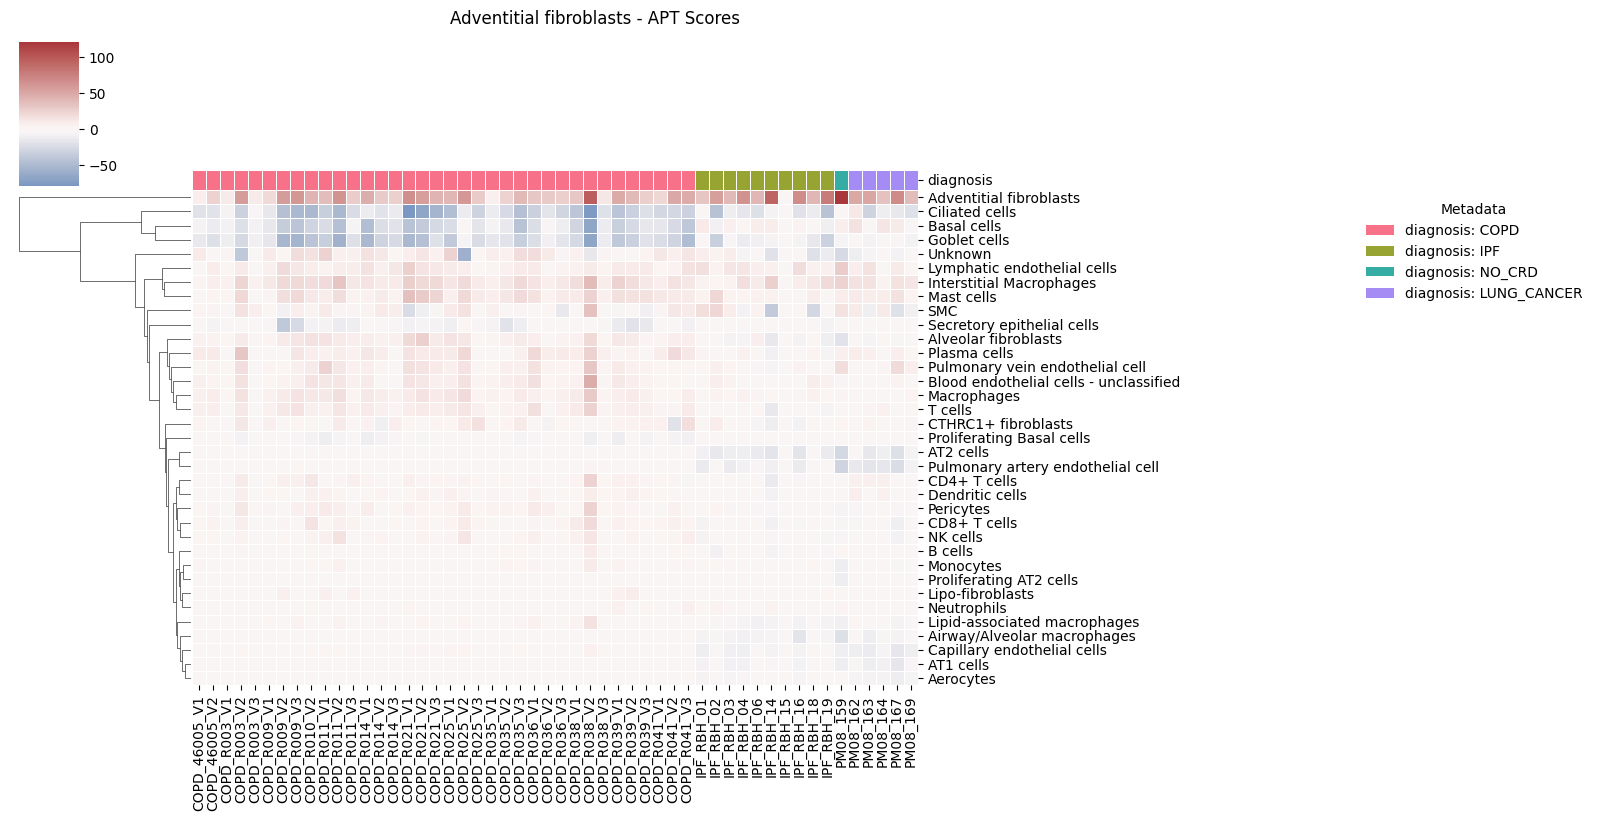

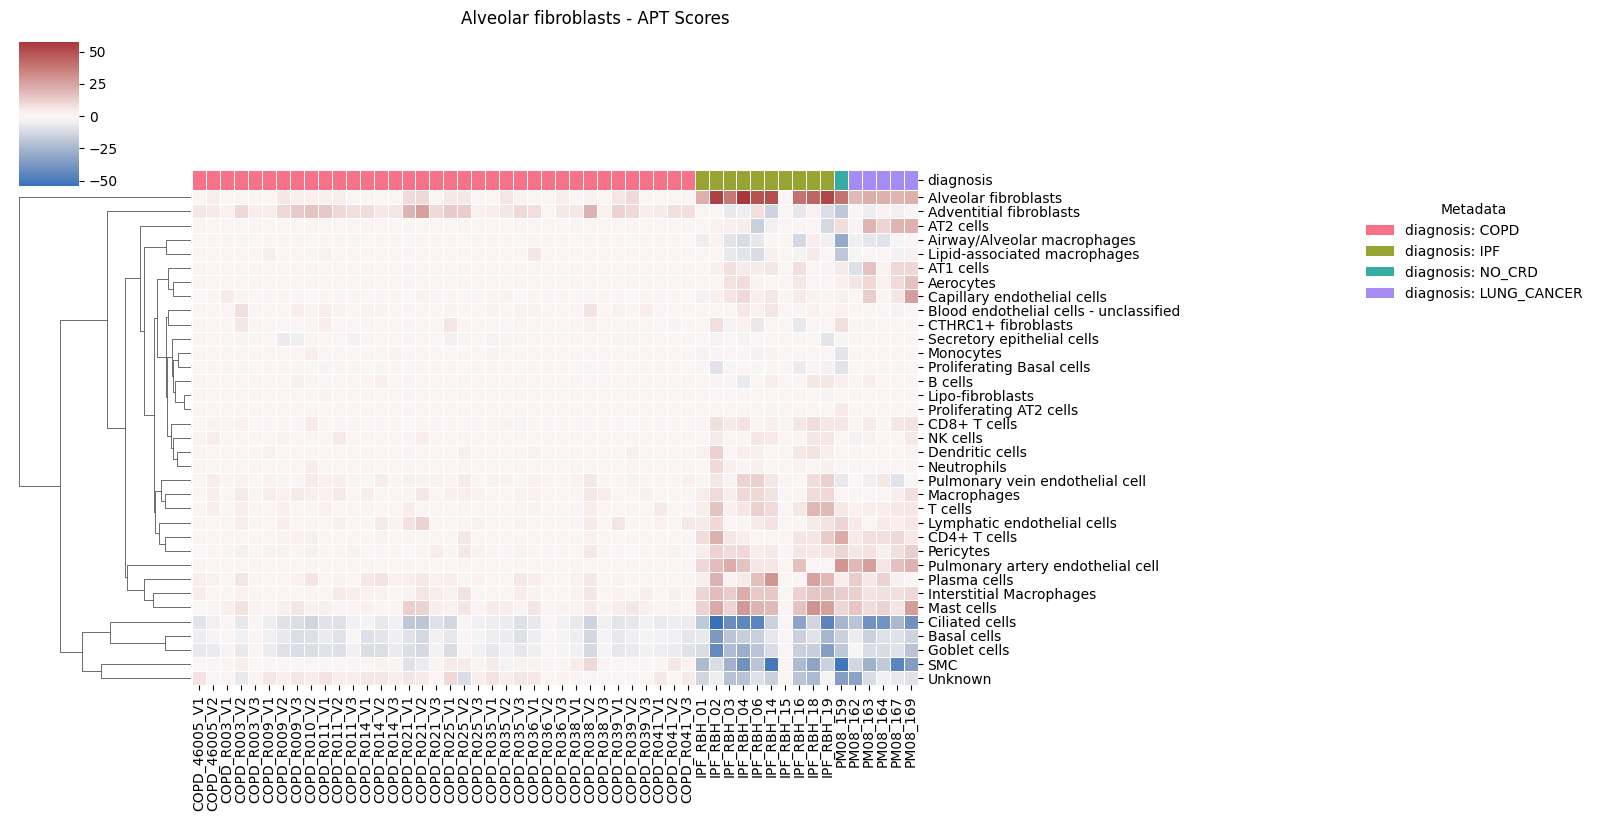

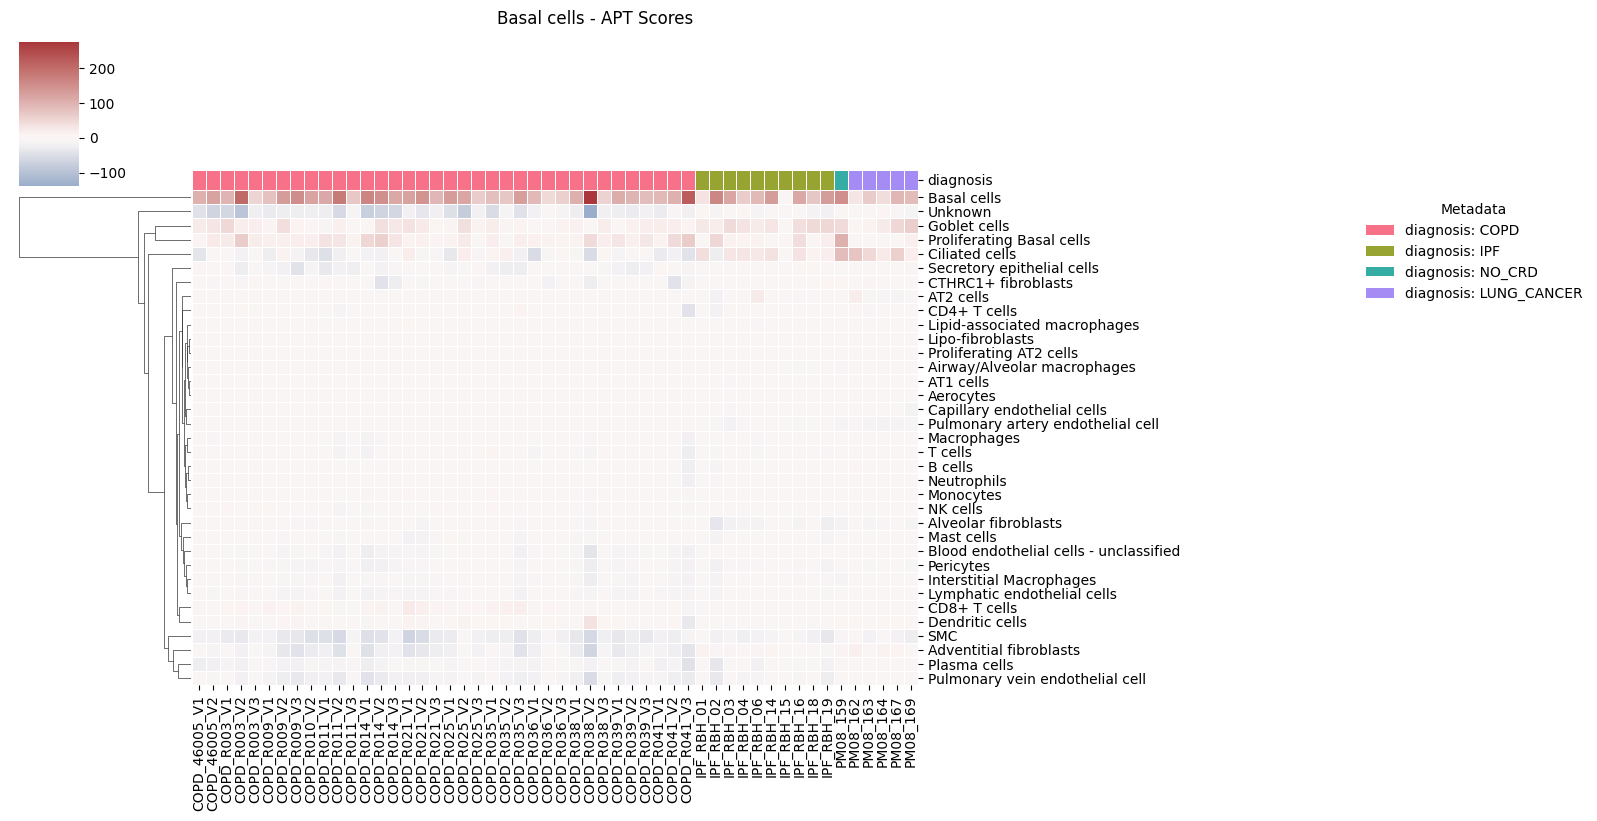

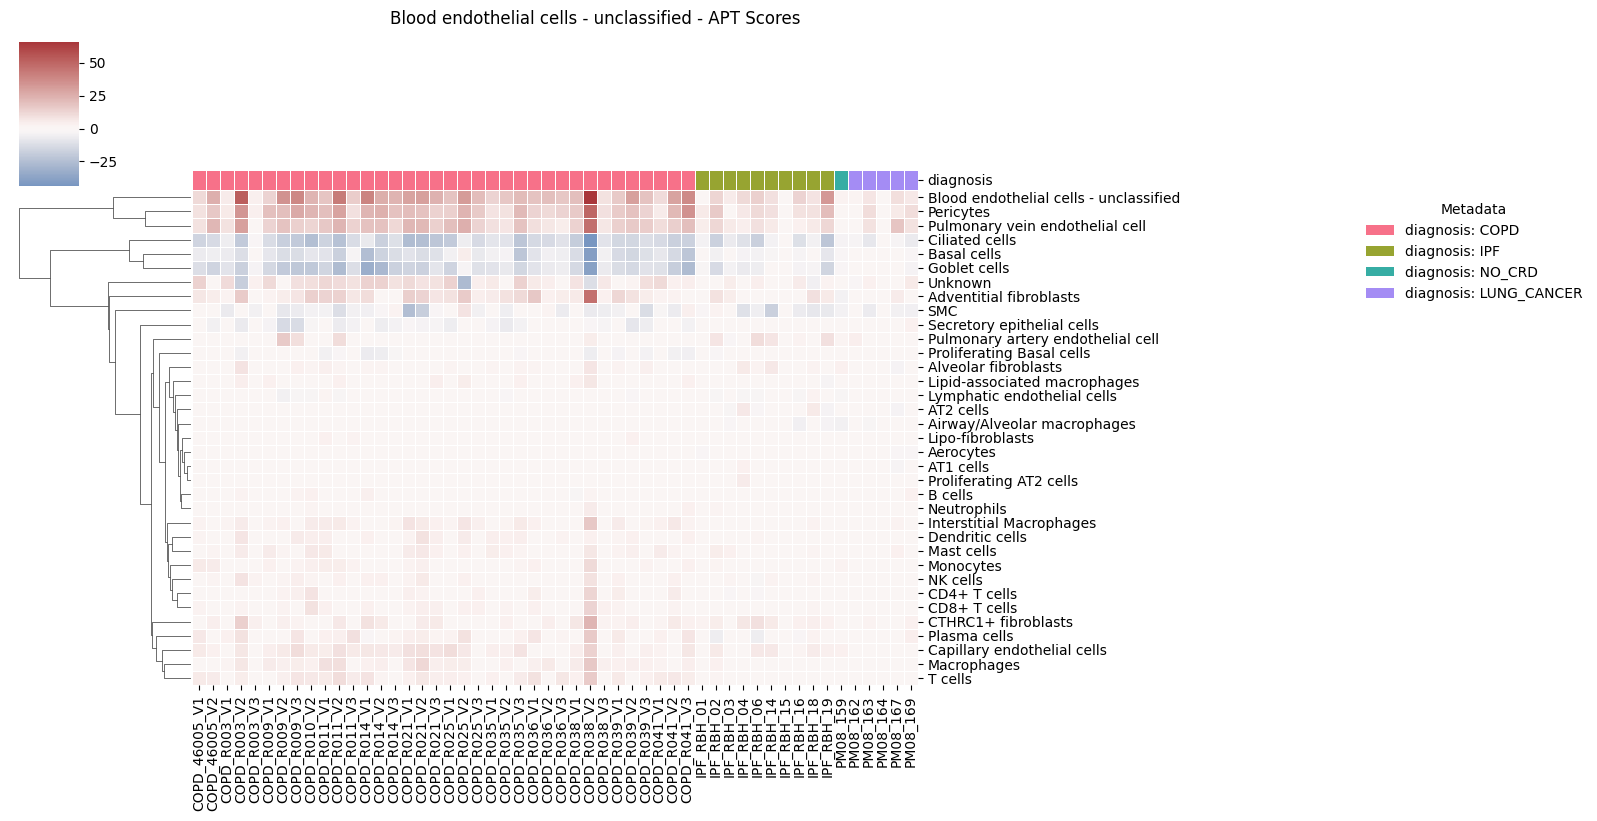

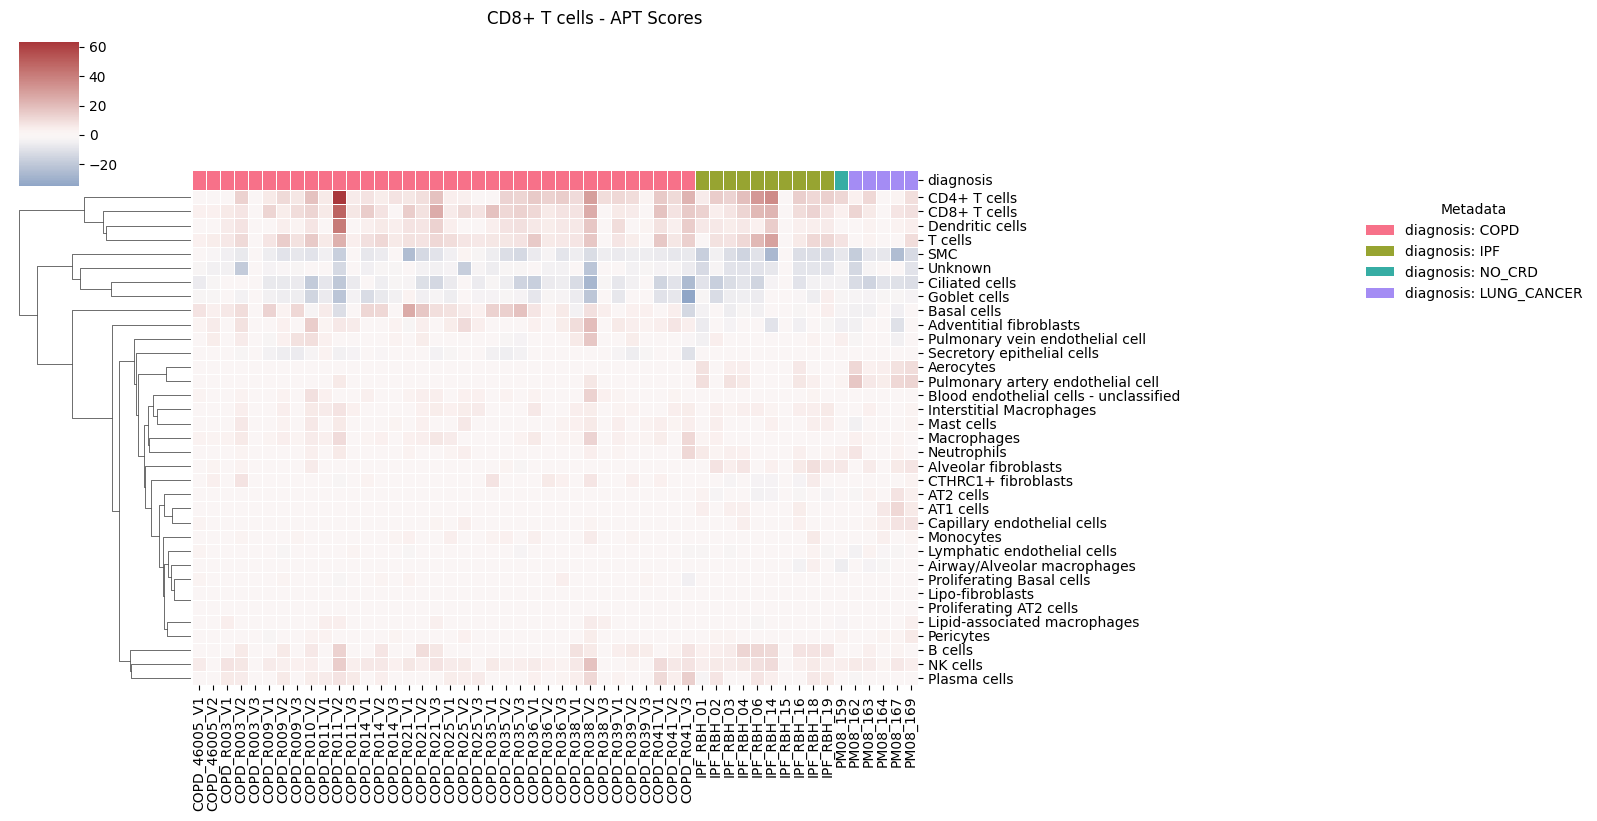

In [6]:
for cell_type in cell_type_list[:5]:
    make_clustermap(
        cell_type=cell_type,
        celltype_dict=celltype_dict,
        meta=meta,
        meta_cols=["diagnosis"],
    )

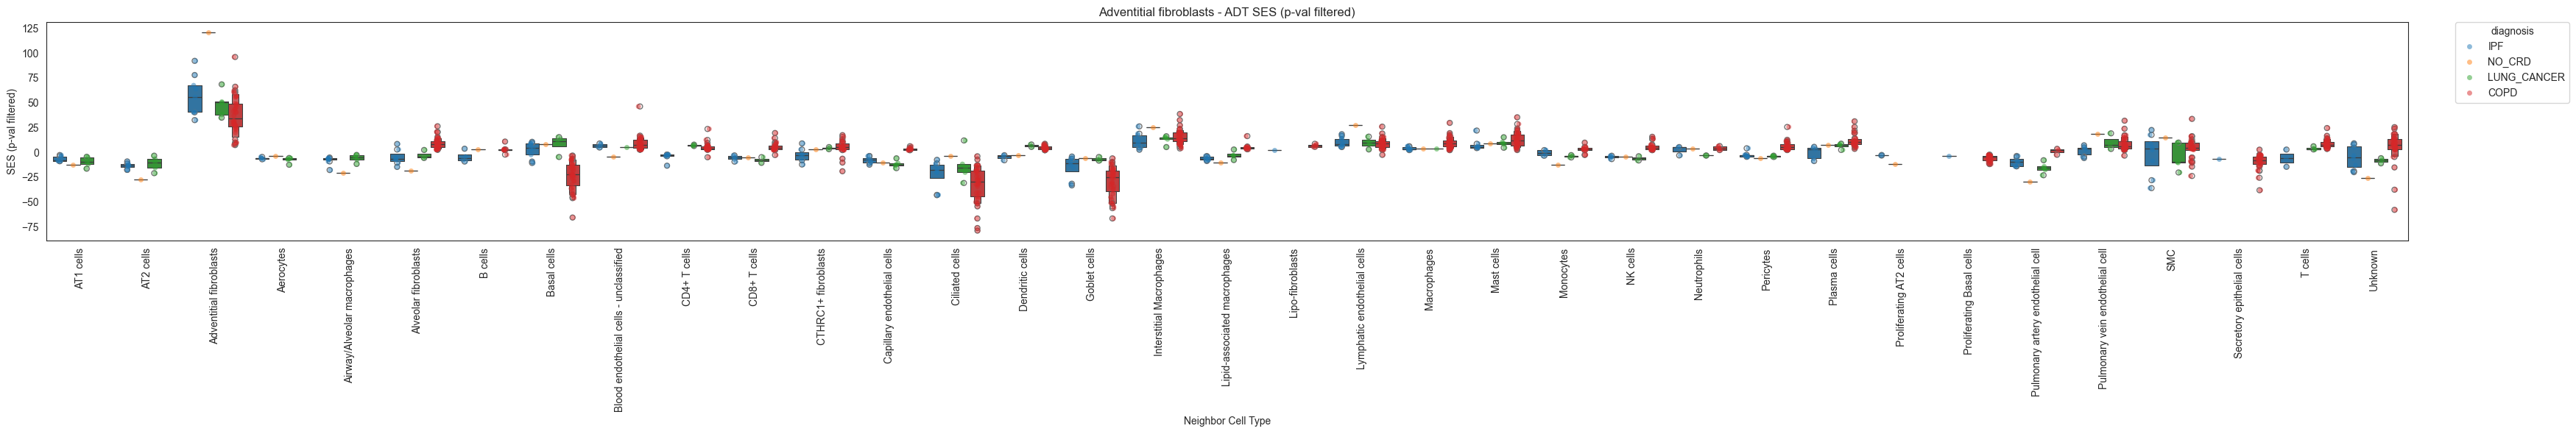

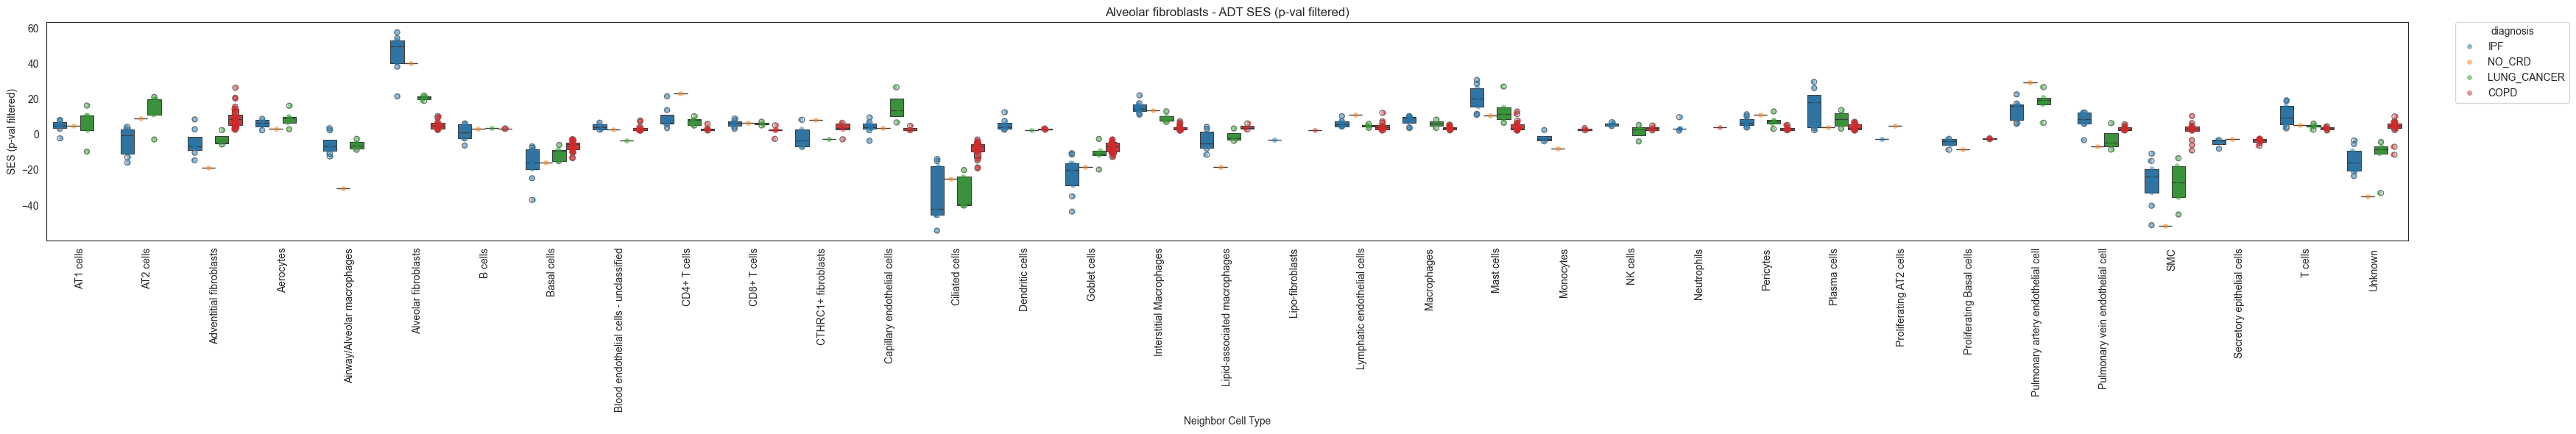

In [ ]:

# List of metadata columns to merge with plot_df
metadata_cols = [
    "diagnosis",
]

for col in metadata_cols:
    if col not in meta.columns:
        raise ValueError(f"Metadata column '{col}' not found in meta dataframe")
    for cell_type in cell_type_list[:2]:
        safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")

        # make directory for this cell type if it doesn't exist
        celltype_dir = barplot_path_zscore / safe_cell_type
        celltype_dir.mkdir(parents=True, exist_ok=True)

        # Extract the dataframe for this cell type across conditions
        celltype_df = pd.DataFrame(celltype_dict[cell_type])

        # Transpose and melt the dataframe for plotting
        plot_df = celltype_df.transpose().reset_index().rename(columns={"index": "ROI"})

        plot_df = plot_df.melt(
            id_vars="ROI", var_name="Neighbor Cell Type", value_name="SES_p_val_filtered"
        )

        # # Add condition column by extracting from ROI name
        plot_df = plot_df.merge(meta, left_on="ROI", right_index=True)

        # Drop NaN values before plotting
        plot_df = plot_df.dropna(subset=["SES_p_val_filtered"])

        sns.set_style("white")
        fig, ax = plt.subplots(figsize=(35, 6))

        sns.stripplot(
            data=plot_df,
            x="Neighbor Cell Type",
            y="SES_p_val_filtered",
            hue=col,
            dodge=True,
            alpha=0.5,
            ax=ax,
        )

        sns.boxenplot(
            data=plot_df,
            x="Neighbor Cell Type",
            y="SES_p_val_filtered",
            hue=col,
            dodge=True,
            ax=ax,
        )

        # Remove duplicate legends
        handles, labels = ax.get_legend_handles_labels()
        n = len(plot_df[col].unique())

        ax.legend(
            handles[:n],
            labels[:n],
            title=col,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
        )

        ax.set_title(f"{cell_type} - ADT SES (p-val filtered)")
        ax.set_ylabel("SES (p-val filtered)")
        ax.tick_params(axis="x", rotation=90)

        plt.tight_layout()
        plt.savefig(
        fig_path / f"{safe_cell_type}_APT_SES_p_val_filtered.pdf",
        bbox_inches="tight",
    )
